# Giai đoạn 6 — Niêm phong khảo sát, dựng bảng huấn luyện TTTH

```
┌──────────────────────────────────────────────────────────────────────────────────────┐
│                                 06_NiemPhongKhaoSat                                  │
└──────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 01_LamSachKhaoSat/khaosat_sach.csv           —  676 phiếu người thật
    • 05_KiemDinhDuLieuSinh/ttth_da_sinh.csv       —  16.296 dòng từ hồ sơ trúng tuyển
    • 05_KiemDinhDuLieuSinh/ket_luan.json          —  phương pháp sinh đã chốt
         │
         ▼
  XỬ LÝ
    1. Dựng 63 đặc trưng cho CẢ HAI phía bằng CÙNG một hàm
    2. KHÔNG gộp — tách hẳn làm hai bảng
    3. Niêm phong 676 phiếu bằng SHA-256  ⭐
    4. Kiểm rò rỉ: dòng huấn luyện có trùng phiếu niêm phong không
    5. Đánh dấu 5 ngành có dữ liệu huấn luyện dẫn xuất từ chính phiếu niêm phong
         │
         ▼
  ĐẦU RA
    • 06_NiemPhongKhaoSat/train_ttth.csv           —  BẢNG HUẤN LUYỆN, 16.296 dòng
    • 06_NiemPhongKhaoSat/khaosat_NIEMPHONG.csv    —  676 phiếu, mở ở Giai đoạn 10
    • 06_NiemPhongKhaoSat/niem_phong_khaosat.json  —  mã băm SHA-256
    • 06_NiemPhongKhaoSat/hinh_6_*.png             —  2 hình
```

## Đây là chỗ Hướng 2 rẽ khỏi Hướng 1

Hướng 1 gộp 676 phiếu khảo sát vào bảng huấn luyện rồi mới chia train/val/test. Hệ quả:
mô hình **được học trên 437 phiếu người thật**, và tập test cũng chứa 117 phiếu người
thật — nhưng những phiếu đó cùng phân phối với phiếu mô hình đã học.

Hướng 2 làm ngược lại:

```
Hướng 1   676 phiếu  ┐
                     ├─▶ train_final 16.972 ─▶ chia 70/15/15 ─▶ học
          16.296 dòng┘

Hướng 2   16.296 dòng ─▶ train_ttth ─▶ chia 70/15/15 ─▶ học ─▶ đo
          676 phiếu   ─▶ NIÊM PHONG ────────────────────────────▶ đo  ⭐
```

**Toàn bộ 676 phiếu người thật trở thành một tập kiểm định độc lập.** Mô hình phân loại
chưa từng nhìn thấy một phiếu nào trong đó. Đây là thứ Hướng 1 không có và là lý do duy
nhất Hướng 2 tồn tại.

## ⚠️ "Độc lập" ở mức nào — phải nói chính xác

Bộ sinh copula **có** học từ 676 phiếu này ở Giai đoạn 3. Không tránh được: nó phải học
phân phối Likert theo ngành từ đâu đó, mà nguồn duy nhất có Likert chính là khảo sát.

Đã cân nhắc cách chữa triệt để — chia khảo sát làm hai, một phần cho bộ sinh học, một
phần niêm phong tuyệt đối. **Không khả thi**: ngành ít phiếu nhất chỉ có 6 phiếu, chia
đôi còn 3–4 phiếu thì không ước lượng nổi ma trận hiệp phương sai 10×10, kể cả có co
ngót Bayes về mức nhóm.

Vậy phát biểu đúng là:

> **Mô hình phân loại chưa từng thấy phiếu nào trong tập niêm phong. Bộ sinh dữ liệu
> thì có.**

Vẫn sạch hơn Hướng 1 rõ rệt, nhưng đừng viết "hoàn toàn độc lập" — sẽ bị bắt lỗi.

## ⚠️ Năm ngành có rò rỉ vòng tròn — phải báo cáo riêng

Năm ngành sau có phiếu khảo sát nhưng **không có hồ sơ trúng tuyển nào**:

| Ngành | Phiếu khảo sát |
|---|---:|
| Luật | 10 |
| Trí tuệ nhân tạo | 15 |
| Quản lý Công nghiệp | 7 |
| Logistics và quản lý chuỗi cung ứng | 10 |
| Du lịch | 10 |

Dòng huấn luyện của chúng được sinh ra từ chính 52 phiếu sẽ bị niêm phong. Nên riêng 5
ngành này, **dữ liệu huấn luyện đi ra từ tập kiểm định** — chúng gần như chắc chắn đạt
điểm rất cao, nhưng con số đó vòng tròn.

Với 34 ngành còn lại thì không có vấn đề đó: điểm thi, tổ hợp và nhãn ngành đều là thật,
lấy từ hồ sơ trúng tuyển; chỉ phần Likert là do copula sinh.

Cách xử lý: cột `rui_ro_vong_tron` đánh dấu 5 ngành này, và **Giai đoạn 10 báo cáo hai
cột** — toàn bộ 39 ngành, và riêng 34 ngành có hồ sơ thật. Chênh lệch giữa hai cột chính
là phần bị thổi lên.

## Mọi dòng huấn luyện ngang nhau

`sample_weight = 1.0` cho cả 16.296 dòng. Cột `nguon` nằm ngoài tập đặc trưng — mô hình
không nhìn thấy nó và không có nhánh xử lý nào rẽ theo nguồn.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    ⚠️ HƯỚNG 2 — khác Hướng 1 ở chỗ căn bản: 676 phiếu khảo sát KHÔNG bao giờ
    vào tập huấn luyện. Giai đoạn 6 niêm phong toàn bộ chúng làm tập kiểm định
    người thật độc lập; chia train/val/test chỉ diễn ra trên phần TTTH.

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu — chỉ để BỘ SINH học
                                     phân phối, không phải để XGBoost học
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở CẢ HAI tập kiểm định ĐÚNG MỘT LẦN:
                                     test TTTH và 676 phiếu khảo sát niêm phong

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")
        # Tập kiểm định NGƯỜI THẬT — niêm phong từ Giai đoạn 6, mở cùng lúc.
        d["khaosat_niemphong"] = pd.read_csv(thu_muc(6) / "khaosat_NIEMPHONG.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

import hashlib

OUT = thu_muc(6)

D = nap(co_ttth=False)
ks = D["train"]
L, C_DIEM = D["likert"], D["diem"]

KL = json.loads((thu_muc(5) / "ket_luan.json").read_text(encoding="utf-8"))
sinh = pd.read_csv(thu_muc(5) / "ttth_da_sinh.csv")

print(f"Phiếu khảo sát   : {len(ks):,} dòng  → SẼ NIÊM PHONG")
print(f"Dòng từ TTTH     : {len(sinh):,} dòng  → bảng huấn luyện")
print(f"   phương pháp   : {KL['phuong_phap_chot']}")
print(f"   AUC phân biệt {KL['auc']:.3f} · sao chép {KL['sao_chep']:.1%}"
      f" · đa dạng {KL['da_dang']:.1%}")
print(f"\nTỉ lệ            : {len(sinh)/len(ks):.1f} dòng huấn luyện / 1 phiếu kiểm định")
print(f"\n⚠️  Hướng 1 gộp cả hai thành {len(ks)+len(sinh):,} dòng rồi mới chia.")
print(f"    Hướng 2 giữ chúng TÁCH BIỆT hoàn toàn.")

Phiếu khảo sát   : 676 dòng  → SẼ NIÊM PHONG
Dòng từ TTTH     : 16,296 dòng  → bảng huấn luyện
   phương pháp   : copula
   AUC phân biệt 0.583 · sao chép 0.6% · đa dạng 96.3%

Tỉ lệ            : 24.1 dòng huấn luyện / 1 phiếu kiểm định

⚠️  Hướng 1 gộp cả hai thành 16,972 dòng rồi mới chia.
    Hướng 2 giữ chúng TÁCH BIỆT hoàn toàn.


## 1. Thống nhất lược đồ hai phía

In [2]:
# Dù không gộp, hai phía vẫn phải qua CÙNG một hàm dac_trung() — nếu không thì
# mô hình học trên lược đồ này rồi được chấm trên lược đồ khác, sai âm thầm.
ks = ks.copy()
ks["to_hop_thi"] = ks.to_hop_thi.astype(str).str.split(" ").str[0]
ks["nguon"] = "khaosat"
ks["ma_nhom"] = ks.ma_nganh.map(D["nhom"])

can = ["ma_nganh", "ma_nhom", "to_hop_thi", "gioi_tinh", "muc_tieu_ma", "nguon"]
ks_g = ks[can + L + C_DIEM].copy()
sinh_g = sinh[can + L + C_DIEM].copy()

assert list(ks_g.columns) == list(sinh_g.columns), "hai phía lệch cột"
print(f"Lược đồ chung: {len(ks_g.columns)} cột")
print(f"   quản lý : {can}")
print(f"   Likert  : {len(L)} · điểm: {len(C_DIEM)}")

print(f"\nNguồn của bảng huấn luyện:")
print(sinh_g.nguon.value_counts().to_string())

Lược đồ chung: 26 cột
   quản lý : ['ma_nganh', 'ma_nhom', 'to_hop_thi', 'gioi_tinh', 'muc_tieu_ma', 'nguon']
   Likert  : 10 · điểm: 10

Nguồn của bảng huấn luyện:
nguon
ttth                 15696
bootstrap_khaosat      600


## 2. Dựng 63 đặc trưng

⚠️ Thống kê điểm để quy z-score tính **CHỈ trên bảng huấn luyện**, không đụng phiếu
niêm phong. Tính trên cả hai thì thông tin của tập kiểm định rò rỉ vào bước chuẩn hoá,
và toàn bộ ý nghĩa của việc niêm phong mất sạch.


In [3]:
# Tổ hợp: lấy hợp của hai phía, vì phiếu niêm phong có thể có tổ hợp mà TTTH
# không có — thiếu cột thì lúc chấm sẽ vỡ. Đây là thông tin về LƯỢC ĐỒ, không phải
# thông tin về nhãn, nên không tính là rò rỉ.
D["to_hop"] = sorted(set(sinh_g.to_hop_thi) | set(ks_g.to_hop_thi))

# Trung bình/độ lệch điểm thì CHỈ lấy từ bảng huấn luyện — đây mới là thống kê
# mang thông tin, để lọt là rò rỉ thật.
g = sinh_g[C_DIEM].astype(float)
D["diem_mu"] = g.mean().values
D["diem_sd"] = g.std().replace(0, 1).values
print(f"Chuẩn hoá điểm học từ {len(sinh_g):,} dòng huấn luyện — KHÔNG đụng phiếu niêm phong")

X_tr = dac_trung(sinh_g, D, co_khao_sat=True)
X_ks = dac_trung(ks_g, D, co_khao_sat=True)

assert list(X_tr.columns) == list(X_ks.columns), "hai phía ra lược đồ khác nhau"
assert X_tr.shape[1] == 63, f"phải đúng 63 đặc trưng, đang có {X_tr.shape[1]}"
print(f"\nHuấn luyện : {X_tr.shape[0]:,} dòng × {X_tr.shape[1]} cột")
print(f"Niêm phong : {X_ks.shape[0]:,} dòng × {X_ks.shape[1]} cột")

nhom_ct = nhom_dac_trung(list(X_tr.columns), D)
for ten, cot in nhom_ct.items():
    print(f"   {ten:<28} {len(cot):>3} cột")

Chuẩn hoá điểm học từ 16,296 dòng huấn luyện — KHÔNG đụng phiếu niêm phong

Huấn luyện : 16,296 dòng × 63 cột
Niêm phong : 676 dòng × 63 cột
   Likert thô                    10 cột
   Likert chuẩn hoá theo người   10 cột
   Thống kê Likert                2 cột
   Điểm thi thô                  10 cột
   Điểm z-score từng môn         10 cột
   Phái sinh từ điểm              4 cột
   Tổ hợp xét tuyển (one-hot)    15 cột
   Nhân khẩu học & mục tiêu       2 cột


## 3. Đánh dấu 5 ngành rò rỉ vòng tròn

In [4]:
# Ngành nào có trong khảo sát mà KHÔNG có hồ sơ trúng tuyển nào → dòng huấn
# luyện của nó dẫn xuất hoàn toàn từ phiếu sẽ bị niêm phong.
co_ttth_that = set(sinh_g[sinh_g.nguon == "ttth"].ma_nganh)
VONG_TRON = sorted(set(ks_g.ma_nganh) - co_ttth_that)

print(f"Ngành có hồ sơ trúng tuyển THẬT : {len(co_ttth_that)}")
print(f"Ngành CHỈ có dữ liệu dẫn xuất   : {len(VONG_TRON)}")
print()
print(f"{'Mã':<10}{'Ngành':<44}{'phiếu k.sát':>12}{'dòng h.luyện':>14}")
print("-" * 80)
for m in VONG_TRON:
    print(f"{m:<10}{D['ma_to_ten'][m][:42]:<44}"
          f"{int((ks_g.ma_nganh==m).sum()):>12}{int((sinh_g.ma_nganh==m).sum()):>14}")
print("-" * 80)
n_ks_vt = int(ks_g.ma_nganh.isin(VONG_TRON).sum())
print(f"{'':54}{n_ks_vt:>12}{int(sinh_g.ma_nganh.isin(VONG_TRON).sum()):>14}")
print(f"\n⚠️  {n_ks_vt}/{len(ks_g)} phiếu niêm phong ({100*n_ks_vt/len(ks_g):.1f}%)"
      f" thuộc 5 ngành này.")
print(f"    Giai đoạn 10 phải báo cáo riêng cột loại bỏ chúng.")

Ngành có hồ sơ trúng tuyển THẬT : 34
Ngành CHỈ có dữ liệu dẫn xuất   : 5

Mã        Ngành                                        phiếu k.sát  dòng h.luyện
--------------------------------------------------------------------------------
7380101   Luật                                                  10           120
7480107   Trí tuệ nhân tạo                                      15           120
7510601   Quản lý Công nghiệp                                    7           120
7510605   Logistics và quản lý chuỗi cung ứng                   10           120
7810101   Du lịch                                               10           120
--------------------------------------------------------------------------------
                                                                52           600

⚠️  52/676 phiếu niêm phong (7.7%) thuộc 5 ngành này.
    Giai đoạn 10 phải báo cáo riêng cột loại bỏ chúng.


## 4. Kiểm rò rỉ trực tiếp

In [5]:
# Một dòng huấn luyện trùng KHÍT một phiếu niêm phong là rò rỉ trực tiếp: mô
# hình đã thấy đúng câu trả lời trước khi được chấm. Giai đoạn 5 đã ràng buộc
# dưới ngưỡng; kiểm lại ở đây trên bảng cuối cùng.
bo_ks = set(map(tuple, ks_g[L].to_numpy(int)))
trung = np.array([tuple(r) in bo_ks for r in sinh_g[L].to_numpy(int)])
n_trung = int(trung.sum())

print(f"Dòng huấn luyện trùng khít Likert của một phiếu niêm phong:")
print(f"   {n_trung:,}/{len(sinh_g):,}  ({100*n_trung/len(sinh_g):.2f}%)")
print(f"   ngưỡng đặt ở Giai đoạn 5: {KL['nguong_sao_chep']:.0%}")
assert n_trung / len(sinh_g) < KL["nguong_sao_chep"], "vượt ngưỡng sao chép"

# Trùng cả Likert LẪN điểm thi mới là bản sao hoàn chỉnh — nghiêm trọng hơn nhiều.
cot_khop = L + C_DIEM
bo_full = set(map(tuple, ks_g[cot_khop].fillna(-1).to_numpy()))
full = np.array([tuple(r) in bo_full for r in sinh_g[cot_khop].fillna(-1).to_numpy()])
print(f"\nTrùng cả Likert LẪN điểm thi: {int(full.sum()):,}"
      f"  ({100*full.mean():.2f}%)")
if full.sum():
    print(f"   Toàn bộ nằm ở 5 ngành vòng tròn:"
          f" {bool(sinh_g.loc[full, 'ma_nganh'].isin(VONG_TRON).all())}")

dd = len(sinh_g[L].drop_duplicates()) / len(sinh_g)
print(f"\nĐa dạng bảng huấn luyện: {dd:.1%} dòng Likert khác nhau")

Dòng huấn luyện trùng khít Likert của một phiếu niêm phong:
   96/16,296  (0.59%)
   ngưỡng đặt ở Giai đoạn 5: 5%

Trùng cả Likert LẪN điểm thi: 1  (0.01%)
   Toàn bộ nằm ở 5 ngành vòng tròn: True

Đa dạng bảng huấn luyện: 96.3% dòng Likert khác nhau


## 5. Ghi hai bảng và NIÊM PHONG

In [6]:
tr = pd.concat([X_tr, sinh_g[["ma_nganh", "ma_nhom", "nguon"]]], axis=1)
tr["rui_ro_vong_tron"] = tr.ma_nganh.isin(VONG_TRON).astype(int)
tr["sample_weight"] = 1.0
tr.to_csv(OUT / "train_ttth.csv", index=False)

kp = pd.concat([X_ks, ks_g[["ma_nganh", "ma_nhom", "nguon"]]], axis=1)
kp["rui_ro_vong_tron"] = kp.ma_nganh.isin(VONG_TRON).astype(int)
kp["sample_weight"] = 1.0
p_kp = OUT / "khaosat_NIEMPHONG.csv"
kp.to_csv(p_kp, index=False)

# ── NIÊM PHONG ───────────────────────────────────────────────────────────
bam = hashlib.sha256(p_kp.read_bytes()).hexdigest()
(OUT / "niem_phong_khaosat.json").write_text(json.dumps({
    "bam_sha256": bam,
    "n_dong": int(len(kp)),
    "n_nganh": int(kp.ma_nganh.nunique()),
    "n_vong_tron": int(kp.rui_ro_vong_tron.sum()),
    "nganh_vong_tron": [int(m) for m in VONG_TRON],
    "mo_o_giai_doan": 10,
    "ghi_chu": "Mô hình phân loại KHÔNG BAO GIỜ được đọc file này trước Giai đoạn 10. "
               "Bộ sinh copula ở Giai đoạn 3 CÓ học từ dữ liệu gốc của nó.",
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"train_ttth.csv        {len(tr):>7,} dòng × {len(tr.columns)} cột")
print(f"khaosat_NIEMPHONG.csv {len(kp):>7,} dòng × {len(kp.columns)} cột")
print(f"\n🔒 NIÊM PHONG SHA-256")
print(f"   {bam}")
print(f"   Giai đoạn 10 kiểm lại mã này trước khi mở.")
assert not set(tr.columns) ^ set(kp.columns), "hai bảng lệch cột"
assert "nguon" not in [c for c in tr.columns if c in X_tr.columns], "nguon lọt vào đặc trưng"

train_ttth.csv         16,296 dòng × 68 cột
khaosat_NIEMPHONG.csv     676 dòng × 68 cột

🔒 NIÊM PHONG SHA-256
   99fb31be34977fccbac79b68f0b18abffd613204b016fdbc9bf20e1b2947ce5b
   Giai đoạn 10 kiểm lại mã này trước khi mở.


   💾 hinh_6_1_hai_bang.png


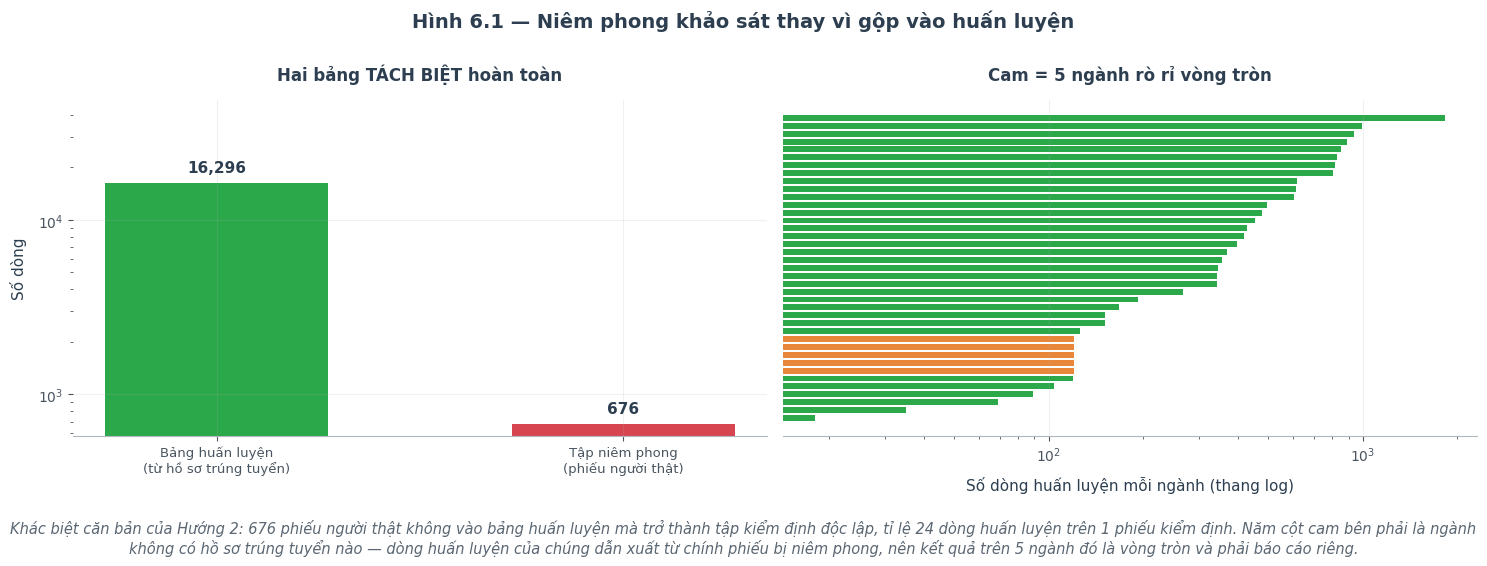

In [7]:
# ═══════════ HÌNH 6.1 — Hai bảng, hai vai trò ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

ct = pd.Series({"Bảng huấn luyện\n(từ hồ sơ trúng tuyển)": len(tr),
                "Tập niêm phong\n(phiếu người thật)": len(kp)})
a1.bar(range(2), ct.values, color=[C_GA, C_THAT], width=.55)
a1.set_xticks(range(2)); a1.set_xticklabels(ct.index, fontsize=9.5)
a1.set_ylabel("Số dòng"); a1.set_yscale("log")
for i, v in enumerate(ct.values):
    a1.text(i, v * 1.15, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
a1.set_title("Hai bảng TÁCH BIỆT hoàn toàn", fontsize=12)
a1.set_ylim(top=ct.max() * 3)

sl = pd.DataFrame({
    "huan_luyen": tr.groupby("ma_nganh").size(),
    "niem_phong": kp.groupby("ma_nganh").size()}).fillna(0).sort_values("huan_luyen")
mau_ = np.where(sl.index.isin(VONG_TRON), C_CAM, C_GA)
a2.barh(range(len(sl)), sl.huan_luyen, color=mau_, height=.75)
a2.set_yticks([]); a2.set_xscale("log")
a2.set_xlabel("Số dòng huấn luyện mỗi ngành (thang log)")
a2.set_title("Cam = 5 ngành rò rỉ vòng tròn", fontsize=12)

fig.suptitle("Hình 6.1 — Niêm phong khảo sát thay vì gộp vào huấn luyện",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_6_1_hai_bang.png",
    f"Khác biệt căn bản của Hướng 2: {len(kp)} phiếu người thật không vào bảng huấn "
    f"luyện mà trở thành tập kiểm định độc lập, tỉ lệ {len(tr)/len(kp):.0f} dòng huấn "
    f"luyện trên 1 phiếu kiểm định. Năm cột cam bên phải là ngành không có hồ sơ trúng "
    f"tuyển nào — dòng huấn luyện của chúng dẫn xuất từ chính phiếu bị niêm phong, nên "
    f"kết quả trên 5 ngành đó là vòng tròn và phải báo cáo riêng.")
plt.show()

   💾 hinh_6_2_o_trong.png


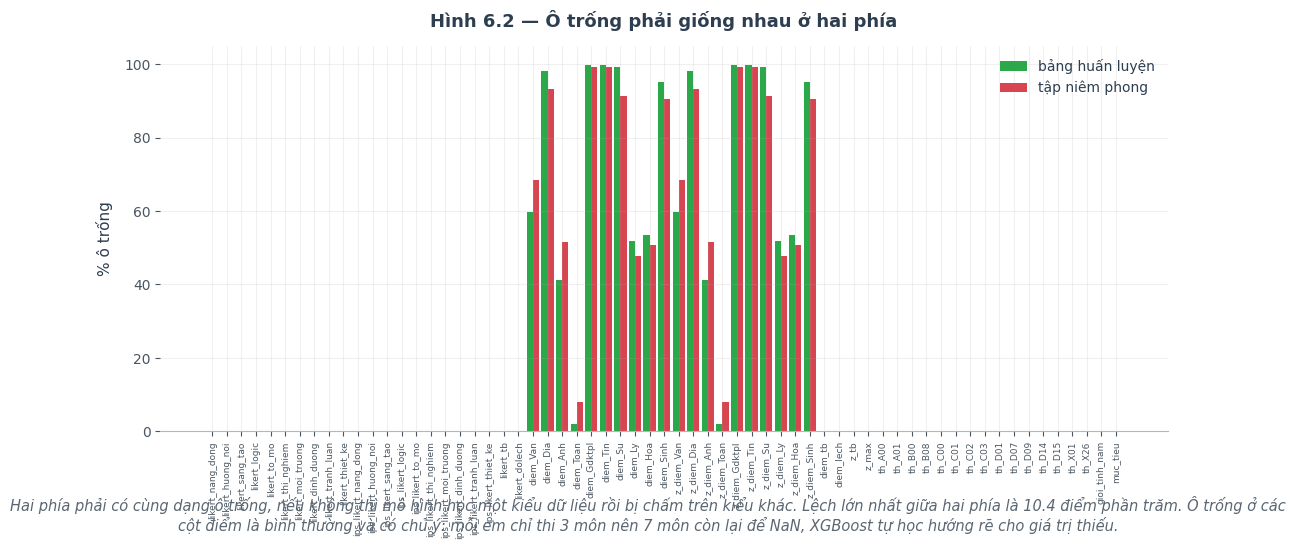

In [8]:
# ═══════════ HÌNH 6.2 — Ô trống theo cột ═══════════
fig, ax = plt.subplots(figsize=(13, 5))
ct_x = [c for c in X_tr.columns]
tr_na = X_tr[ct_x].isna().mean().values * 100
kp_na = X_ks[ct_x].isna().mean().values * 100
x = np.arange(len(ct_x)); w_ = .42
ax.bar(x - w_/2, tr_na, w_, color=C_GA, label="bảng huấn luyện")
ax.bar(x + w_/2, kp_na, w_, color=C_THAT, label="tập niêm phong")
ax.set_xticks(x); ax.set_xticklabels(ct_x, rotation=90, fontsize=6.5)
ax.set_ylabel("% ô trống"); ax.legend(fontsize=10)
ax.set_title("Hình 6.2 — Ô trống phải giống nhau ở hai phía")
lech = float(np.abs(tr_na - kp_na).max())
luu(fig, OUT, "hinh_6_2_o_trong.png",
    f"Hai phía phải có cùng dạng ô trống, nếu không thì mô hình học một kiểu dữ liệu "
    f"rồi bị chấm trên kiểu khác. Lệch lớn nhất giữa hai phía là {lech:.1f} điểm phần "
    f"trăm. Ô trống ở các cột điểm là bình thường và có chủ ý: mỗi em chỉ thi 3 môn nên "
    f"7 môn còn lại để NaN, XGBoost tự học hướng rẽ cho giá trị thiếu.")
plt.show()

In [9]:
tom_tat("GIAI ĐOẠN 6 — NIÊM PHONG KHẢO SÁT (HƯỚNG 2)", [
    f"BẢNG HUẤN LUYỆN   train_ttth.csv",
    f"   {len(tr):>7,} dòng × 63 đặc trưng",
    f"   {tr.ma_nganh.nunique():>7} ngành · trọng số 1.0 đều nhau",
    "",
    f"TẬP NIÊM PHONG    khaosat_NIEMPHONG.csv   🔒",
    f"   {len(kp):>7,} phiếu người thật",
    f"   {kp.ma_nganh.nunique():>7} ngành",
    f"   mã băm {bam[:40]}…",
    "",
    f"Tỉ lệ             {len(tr)/len(kp):.0f} dòng huấn luyện / 1 phiếu kiểm định",
    f"Rò rỉ trực tiếp   {100*n_trung/len(sinh_g):.2f}% dòng trùng Likert phiếu niêm phong",
    "",
    f"⚠️  {len(VONG_TRON)} ngành rò rỉ vòng tròn ({n_ks_vt} phiếu niêm phong):",
] + [f"      {D['ma_to_ten'][m][:44]}" for m in VONG_TRON] + [
    "",
    "Phát biểu ĐÚNG cho báo cáo:",
    "   Mô hình phân loại chưa từng thấy phiếu nào trong tập niêm phong.",
    "   Bộ sinh dữ liệu ở Giai đoạn 3 thì CÓ.",
    "",
    "⚠️  Giai đoạn 7 chia train/val/test CHỈ trên train_ttth.csv",
])
print(f"\n✅ train_ttth.csv · khaosat_NIEMPHONG.csv · niem_phong_khaosat.json"
      f" · 2 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                GIAI ĐOẠN 6 — NIÊM PHONG KHẢO SÁT (HƯỚNG 2)                 ║
╠════════════════════════════════════════════════════════════════════════════╣
║ BẢNG HUẤN LUYỆN   train_ttth.csv                                           ║
║     16,296 dòng × 63 đặc trưng                                             ║
║         39 ngành · trọng số 1.0 đều nhau                                   ║
║                                                                            ║
║ TẬP NIÊM PHONG    khaosat_NIEMPHONG.csv   🔒                                ║
║        676 phiếu người thật                                                ║
║         39 ngành                                                           ║
║    mã băm 99fb31be34977fccbac79b68f0b18abffd613204…                        ║
║                                                                            ║
║ Tỉ lệ             24 dòng huấn luyện / 1 phiếu kiể